In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\hp\Downloads\House Price Prediction Dataset.csv")

In [3]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [4]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [6]:
df=df.drop('Id', axis=1)

In [8]:
df['Location'].unique()

<StringArray>
['Downtown', 'Suburban', 'Urban', 'Rural']
Length: 4, dtype: str

In [9]:
encoded={'Downtown':1, 'Suburban':2, 'Urban':3, 'Rural':4}

In [10]:
df['Location']=df['Location'].map(encoded)

In [11]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,1,Excellent,No,149919
1,4272,5,4,3,1958,1,Excellent,No,424998
2,3592,2,2,3,1938,1,Good,No,266746
3,966,4,2,2,1902,2,Fair,Yes,244020
4,4926,1,4,2,1975,1,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,Poor,No,295620
1996,3046,5,2,1,2019,2,Poor,Yes,580929
1997,1062,5,1,2,1903,4,Poor,No,476925
1998,4062,3,1,2,1936,3,Excellent,Yes,161119


In [12]:
df['Condition'].unique()

<StringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str

In [13]:
encoded2={'Excellent':4, 'Good':3, 'Fair':2, 'Poor':0}

In [14]:
df['Condition']=df['Condition'].map(encoded2)

In [15]:
df['Garage']=df['Garage'].map({'Yes':1, 'No':0})

In [16]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,1,4,0,149919
1,4272,5,4,3,1958,1,4,0,424998
2,3592,2,2,3,1938,1,3,0,266746
3,966,4,2,2,1902,2,2,1,244020
4,4926,1,4,2,1975,1,2,1,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,0,0,295620
1996,3046,5,2,1,2019,2,0,1,580929
1997,1062,5,1,2,1903,4,0,0,476925
1998,4062,3,1,2,1936,3,4,1,161119


In [18]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import seaborn as sns

<Axes: ylabel='Count'>

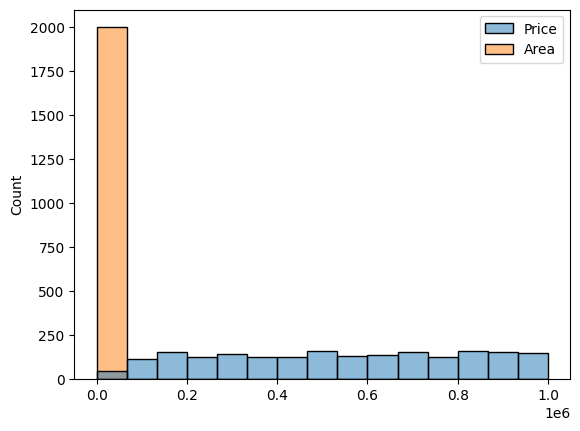

In [25]:
sns.histplot([df.Price, df.Area])

<Axes: >

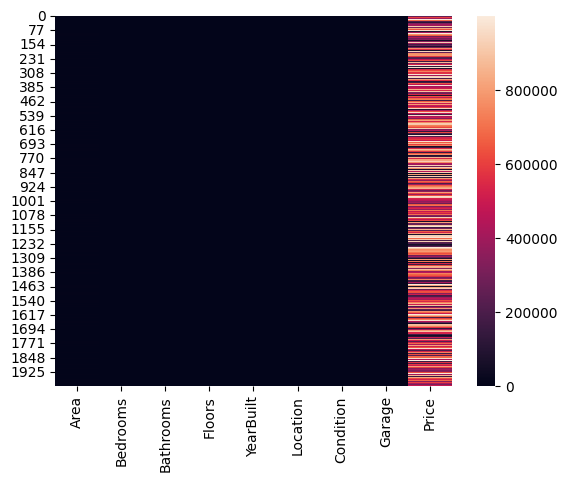

In [28]:
sns.heatmap(df)

In [31]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector

In [30]:
df

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,1,4,0,149919
1,4272,5,4,3,1958,1,4,0,424998
2,3592,2,2,3,1938,1,3,0,266746
3,966,4,2,2,1902,2,2,1,244020
4,4926,1,4,2,1975,1,2,1,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,2,0,0,295620
1996,3046,5,2,1,2019,2,0,1,580929
1997,1062,5,1,2,1903,4,0,0,476925
1998,4062,3,1,2,1936,3,4,1,161119


In [33]:
reg=SVR()

In [34]:
SequentialFeatureSelector(reg, n_features_to_select=5)

,estimator estimator: estimator instanceAn unfitted estimator.,SVR()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",5
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [37]:
x=df.drop('Price', axis=1)
y=df.Price

In [38]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42, )

In [39]:
xtrain

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
968,4483,4,4,3,1933,3,4,0
240,1062,3,3,1,1970,1,3,0
819,1422,3,4,1,1993,3,3,1
692,2658,2,3,1,1972,4,0,1
420,3286,2,4,1,1981,4,4,1
...,...,...,...,...,...,...,...,...
1130,3483,5,3,3,1931,1,3,1
1294,1747,3,3,2,1941,1,2,1
860,1484,2,3,3,1973,1,3,0
1459,3456,5,4,1,1955,1,3,1


In [40]:
xtest

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
1860,633,1,4,2,1901,3,2,0
353,3856,1,1,2,1901,3,2,0
1333,1598,5,4,1,2013,3,4,0
905,1705,3,1,2,1996,1,3,1
1289,2564,5,2,3,1994,1,3,1
...,...,...,...,...,...,...,...,...
965,1811,1,3,3,1970,4,0,0
1284,794,3,2,2,2013,1,0,1
1739,3540,4,4,2,1939,1,0,1
261,3670,5,2,2,1910,1,3,1


In [ ]:
reg.fit(xtrain, ytrain,)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1
